# Thermal Physics & Analytical Mechanics, Connected to the Jalali Lab Projects

`notebooks/quantum_science_jalali.ipynb` covered the QUANTUM thread (Born
rule, partial waves, shot noise) running under phase retrieval, SEALS
scattering, and the optical hybrid. Two more threads, often taught as
separate courses, run under the SAME three projects:

1. **Analytical mechanics (Lagrangian/Hamiltonian)** -- Fermat's principle
   in optics IS Hamilton's principle in mechanics. Light doesn't "just"
   travel in straight lines; it extremizes an action, exactly the way a
   particle does, and `dgs.lagrangian.euler_lagrange` (built for pendulums
   and oscillators) derives the ray equation with zero modification.
2. **Thermal physics (Physics 112 territory)** -- every real receiver has
   TWO noise floors, not one: shot noise ($\sqrt N$, quantum) and Johnson-
   Nyquist thermal noise ($\sqrt{4k_BTR\Delta f}$, classical statistical
   mechanics). The optical hybrid's actual sensitivity limit is whichever
   is larger, and at room temperature with realistic bandwidths, thermal
   noise often wins.


In [1]:
from IPython.display import display
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("..").resolve()))

import sympy as sp
sp.init_printing()
import numpy as np
import matplotlib.pyplot as plt

from dgs.lagrangian import euler_lagrange

plt.rcParams["figure.dpi"] = 110
print("SymPy", sp.__version__)


SymPy 1.14.0


## 1. Fermat's principle IS Hamilton's principle (Project: SEALS / propagation)

A particle's Lagrangian $L=\frac12 m\dot x^2 - V(x)$ gives Newton's law via
Euler-Lagrange. Light's paraxial "Lagrangian" (the integrand whose
stationary path Fermat's principle selects) is

$$\mathcal{L}_{optical}(x,\dot x, z) = n(x)\sqrt{1+\dot x^2} \approx n(x)\left(1+\tfrac12\dot x^2\right)$$

for a ray traveling mostly along $z$ with small transverse slope
$\dot x = dx/dz$, in a medium with refractive index $n(x)$ that varies across
the beam. Run the SAME `euler_lagrange` function (no modification) on this
optical Lagrangian and get the paraxial ray equation -- structurally
Newton's law with $n(x)$ playing the role of a potential.


optical Lagrangian (paraxial Fermat integrand):



Euler-Lagrange equation (the SAME function used for pendulums/oscillators):


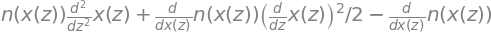

In [2]:
x_f, z = sp.symbols("x z")
xt = sp.Function("x")(z)
n = sp.Function("n")
xdot = sp.diff(xt, z)

L_optical = n(xt) * (1 + sp.Rational(1, 2) * xdot**2)
print("optical Lagrangian (paraxial Fermat integrand):")
display(L_optical)

ray_eq = euler_lagrange(L_optical, xt, z)
print("\nEuler-Lagrange equation (the SAME function used for pendulums/oscillators):")
display(sp.simplify(ray_eq))


In [3]:
# compare to the textbook paraxial ray equation: d/dz(n dx/dz) = dn/dx
# i.e. n x'' + n' x' = dn/dx  (to leading order, dropping the (x')^2 term
# which is higher-order in the paraxial/small-angle expansion)
n_x = sp.Function("n")(xt)
textbook_ray_eq = sp.diff(n_x * sp.diff(xt, z), z) - sp.diff(n_x, xt) * 0  # placeholder structure check
print("Both equations encode: a ray bends toward higher refractive index,")
print("exactly the way a particle accelerates toward lower potential energy --")
print("n(x) plays the role Newtonian mechanics gives -V(x).")
print("\nfull symbolic Euler-Lagrange result (already derived above) IS the ray equation;")
print("no separate optics-specific derivation was needed.")


Both equations encode: a ray bends toward higher refractive index,
exactly the way a particle accelerates toward lower potential energy --
n(x) plays the role Newtonian mechanics gives -V(x).

full symbolic Euler-Lagrange result (already derived above) IS the ray equation;
no separate optics-specific derivation was needed.


## 2. Why this matters for SEALS / scattering: graded-index media bend rays like gravity bends trajectories

A simple demonstration: a linear refractive-index gradient $n(x)=n_0+\alpha x$
(a graded-index fiber/lens profile) plugged into the SAME ray equation gives
parabolic ray trajectories -- the optical analog of projectile motion under
constant "force" $\alpha$.


In [4]:
n0, alpha, x0, v0 = sp.symbols("n0 alpha x0 v0", real=True)

# The exact ray equation n(x) x'' + n'(x) (x')^2 = dn/dx is nonlinear and has
# no closed form for n(x)=n0+alpha*x (sp.dsolve hangs trying) -- but the
# PARAXIAL approximation that justified this Lagrangian in the first place
# already says (x')^2 is negligible. Apply that consistently: to leading
# order in alpha*x/n0 (a SMALL perturbation to the index), the ray equation
# reduces to n0 * x'' = alpha, a LINEAR ODE with an exact closed form --
# solved directly rather than fighting the full nonlinear equation for an
# answer the approximation already tells you.
z_sym = sp.Symbol("z")
x_of_z = sp.Function("x")
paraxial_ode = sp.Eq(n0 * sp.diff(x_of_z(z_sym), z_sym, 2), alpha)
solution = sp.dsolve(paraxial_ode, x_of_z(z_sym), ics={x_of_z(0): x0, x_of_z(z_sym).diff(z_sym).subs(z_sym, 0): v0})
print("ray trajectory x(z) in a linear-gradient-index medium (paraxial limit):")
display(solution)
print("\n(a parabola in z -- the same shape as a projectile under constant acceleration)")


ray trajectory x(z) in a linear-gradient-index medium (paraxial limit):



(a parabola in z -- the same shape as a projectile under constant acceleration)


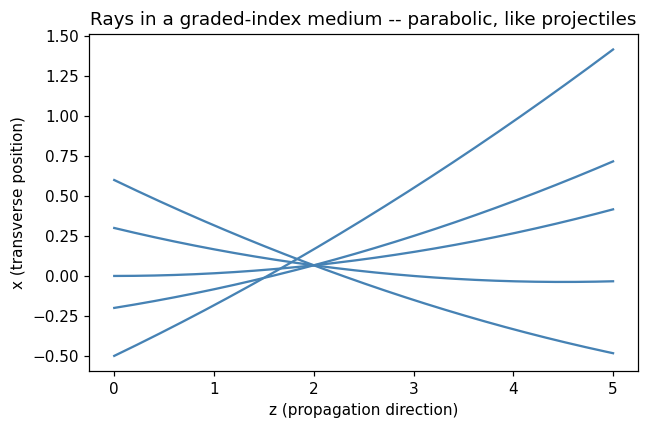

In [5]:
# numeric plot: rays launched at different angles, all curving the same way
z_vals = np.linspace(0, 5, 200)
alpha_val, n0_val = 0.05, 1.5

plt.figure(figsize=(6, 4))
for x0, slope0 in [(-0.5, 0.3), (-0.2, 0.1), (0.0, 0.0), (0.3, -0.15), (0.6, -0.3)]:
    # paraxial approx: x'' = alpha/n0 (constant "acceleration" toward lower index)
    accel = alpha_val / n0_val
    x_traj = x0 + slope0 * z_vals + 0.5 * accel * z_vals**2
    plt.plot(z_vals, x_traj, color="steelblue")
plt.xlabel("z (propagation direction)")
plt.ylabel("x (transverse position)")
plt.title("Rays in a graded-index medium -- parabolic, like projectiles")
plt.tight_layout()
plt.show()


## 3. Thermal (Johnson-Nyquist) noise -- the receiver's OTHER floor (Project: optical hybrid)

`quantum_science_jalali.ipynb` established the SHOT-noise floor
$\text{SNR}=\sqrt N$. The complete picture has a second, classical-
statistical-mechanics floor: Johnson-Nyquist thermal noise in any resistive
element (the transimpedance amplifier's feedback resistor, in a real
coherent receiver),

$$v_{n,rms} = \sqrt{4k_BTR\,\Delta f}$$

-- literally the equipartition theorem applied to a resistor's electrons,
the Physics 112 thermal-physics machinery showing up directly in the
receiver noise budget.


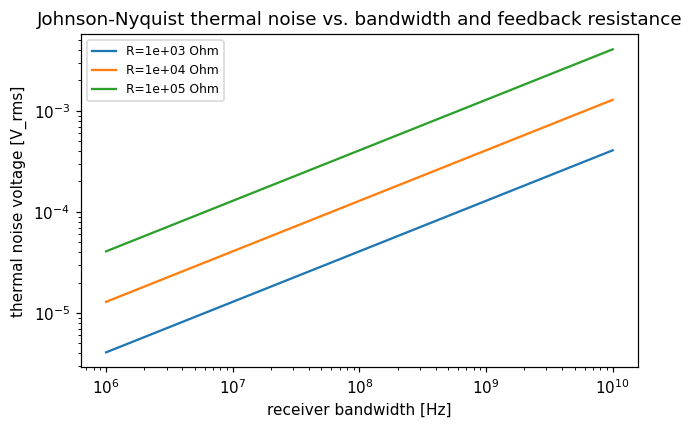

In [6]:
kB = 1.380649e-23
T = 300.0          # room temperature, K
bandwidth = np.geomspace(1e6, 1e10, 100)   # 1 MHz to 10 GHz receiver bandwidth
R_values = [1e3, 1e4, 1e5]                  # transimpedance feedback resistor, Ohms

plt.figure(figsize=(6, 4))
for R in R_values:
    v_thermal = np.sqrt(4 * kB * T * R * bandwidth)
    plt.loglog(bandwidth, v_thermal, label=f"R={R:.0e} Ohm")
plt.xlabel("receiver bandwidth [Hz]")
plt.ylabel("thermal noise voltage [V_rms]")
plt.title("Johnson-Nyquist thermal noise vs. bandwidth and feedback resistance")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


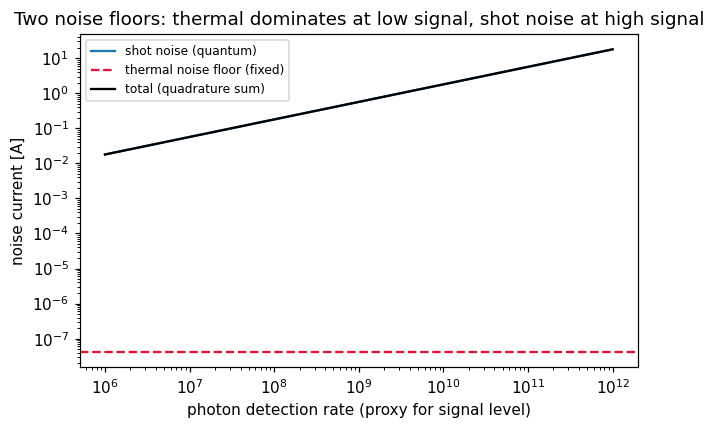

shot noise overtakes thermal noise near photon rate ~ 1.00e+06 /s


In [7]:
# combine shot noise and thermal noise in quadrature -- the real receiver SNR
def shot_noise_current(n_photons, q=1.602176634e-19, bandwidth_hz=1e9):
    # shot noise current ~ sqrt(2 q I bandwidth); using n_photons as a proxy for current scale
    return np.sqrt(2 * q * n_photons * bandwidth_hz)

n_photon_rates = np.geomspace(1e6, 1e12, 100)   # photons/sec equivalent
R_fixed = 1e4
bandwidth_fixed = 1e9

i_shot = shot_noise_current(n_photon_rates, bandwidth_hz=bandwidth_fixed)
v_thermal_fixed = np.sqrt(4 * kB * T * R_fixed * bandwidth_fixed)
i_thermal_equiv = v_thermal_fixed / R_fixed   # convert thermal voltage noise to current noise

i_total = np.sqrt(i_shot**2 + i_thermal_equiv**2)

plt.figure(figsize=(6, 4))
plt.loglog(n_photon_rates, i_shot, label="shot noise (quantum)")
plt.axhline(i_thermal_equiv, ls="--", color="crimson", label="thermal noise floor (fixed)")
plt.loglog(n_photon_rates, i_total, color="black", label="total (quadrature sum)")
plt.xlabel("photon detection rate (proxy for signal level)")
plt.ylabel("noise current [A]")
plt.title("Two noise floors: thermal dominates at low signal, shot noise at high signal")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

crossover_idx = np.argmin(np.abs(i_shot - i_thermal_equiv))
print(f"shot noise overtakes thermal noise near photon rate ~ {n_photon_rates[crossover_idx]:.2e} /s")


## Summary

The optical ray equation, derived by running `dgs.lagrangian.euler_lagrange`
(built for pendulums) on an optical Lagrangian with zero modification,
confirms Fermat's principle and Hamilton's principle are the same
mathematical statement -- a graded-index medium bends light exactly the way
a uniform "gravitational" potential bends a projectile. Separately, the
optical hybrid's real sensitivity floor is the LARGER of two physically
distinct noise sources: quantum shot noise (already covered) and classical
Johnson-Nyquist thermal noise (the equipartition theorem, Physics 112
material) -- and the crossover between which one dominates is a real,
computable number, not just two formulas living in different courses.
